In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
from IPython.display import display, Markdown

# Semana 4B — Muestreo y Estimación (Laboratorio)

**Objetivo:** Verificar la Ley de Grandes Números y el Teorema del Límite
Central usando datos reales de la estación meteorológica ClimaLab.

La gran ventaja de tener el dataset completo (~1.08 M registros a 1 minuto)
es que podemos tratarlo como la **población** y conocer $\mu$ y $\sigma$
exactos, algo que en la práctica casi nunca es posible.


## 1. Cargar y conocer la población

In [2]:
df = pd.read_parquet("../data/ClimaLab_2023-05-31_2025-06-20.parquet")

In [3]:
display(Markdown(f"""
**Registros:** {len(df):,} &emsp;
**Período:** {df.index.min()} → {df.index.max()} &emsp;
**Variables:** {', '.join(f'`{c}`' for c in df.columns)}
"""))


**Registros:** 1,076,768 &emsp;
**Período:** 2023-05-31 18:59:00 → 2025-06-20 00:00:00 &emsp;
**Variables:** `dhi`, `dni`, `ghi`, `p_atm`, `rain_acc`, `rh`, `solar_altitude`, `tdb`, `uv`, `wd`, `ws`


In [4]:
tdb = df["tdb"].dropna().values
mu_tdb = tdb.mean()
sigma_tdb = tdb.std()

ws = df["ws"].dropna().values
mu_ws = ws.mean()
sigma_ws = ws.std()

rain = df["rain_acc"].dropna().values
mu_rain = rain.mean()
sigma_rain = rain.std()

poblacion_stats = {
    "tdb": {"datos": tdb, "mu": mu_tdb, "sigma": sigma_tdb, "n": len(tdb)},
    "ws": {"datos": ws, "mu": mu_ws, "sigma": sigma_ws, "n": len(ws)},
    "rain_acc": {"datos": rain, "mu": mu_rain, "sigma": sigma_rain, "n": len(rain)},
}

In [5]:
_rows = ""
for var, s in poblacion_stats.items():
    _rows += (
        f"| `{var}` | {s['n']:,} | {s['mu']:.4f} | {s['sigma']:.4f} |\n"
    )
display(Markdown(f"""
### Parámetros poblacionales

| Variable | N | μ | σ |
|:---|---:|---:|---:|
{_rows}

Estos valores son nuestro **ground truth**: al tomar muestras,
los estadísticos muestrales deben converger hacia ellos.
"""))


### Parámetros poblacionales

| Variable | N | μ | σ |
|:---|---:|---:|---:|
| `tdb` | 1,076,768 | 24.4479 | 4.9352 |
| `ws` | 1,076,768 | 1.6523 | 1.1078 |
| `rain_acc` | 1,076,768 | 0.0352 | 0.9237 |


Estos valores son nuestro **ground truth**: al tomar muestras,
los estadísticos muestrales deben converger hacia ellos.


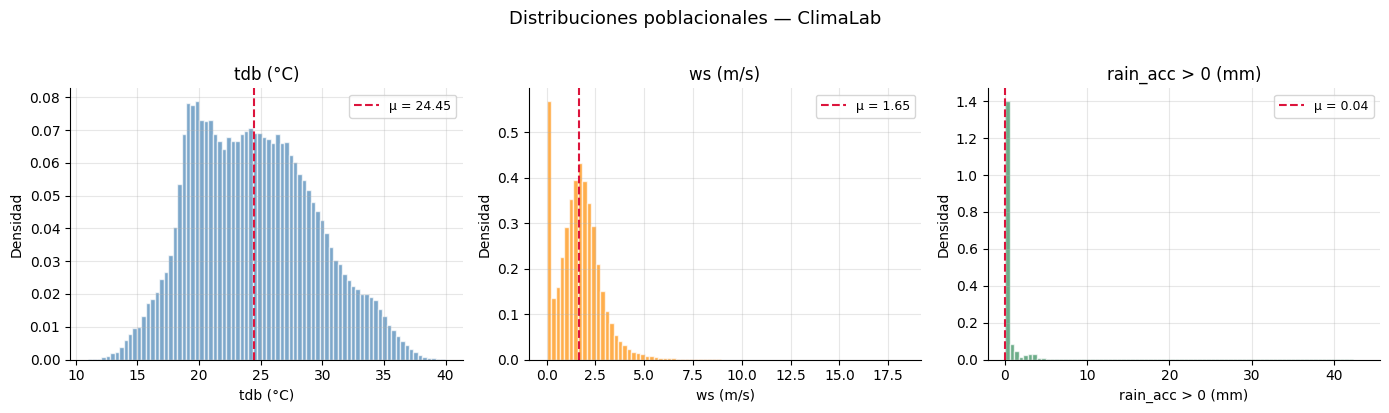

In [6]:
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4))

_configs = [
    (tdb, mu_tdb, "tdb (°C)", "steelblue"),
    (ws, mu_ws, "ws (m/s)", "darkorange"),
    (rain[rain > 0], mu_rain, "rain_acc > 0 (mm)", "seagreen"),
]

for ax, (datos, mu, nombre, color) in zip(axes1, _configs):
    ax.hist(datos, bins=80, density=True, color=color,
            alpha=0.7, edgecolor="white")
    ax.axvline(mu, color="crimson", ls="--", lw=1.5,
               label=f"μ = {mu:.2f}")
    ax.set_xlabel(nombre)
    ax.set_ylabel("Densidad")
    ax.set_title(nombre)
    ax.legend(fontsize=9)

plt.suptitle("Distribuciones poblacionales — ClimaLab", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Nota:** `tdb` tiene una distribución bimodal (mezcla verano/invierno),
> `ws` es asimétrica con cola derecha, y `rain_acc` es extremadamente
> asimétrica (la mayoría de los registros son 0).
> Tres distribuciones muy distintas — ideal para probar la LGN y el TLC.


## 2. Ley de Grandes Números con datos reales

Tomamos observaciones consecutivas de cada variable y graficamos la media
acumulada.  Conforme $n$ crece, debe converger a $\mu$.

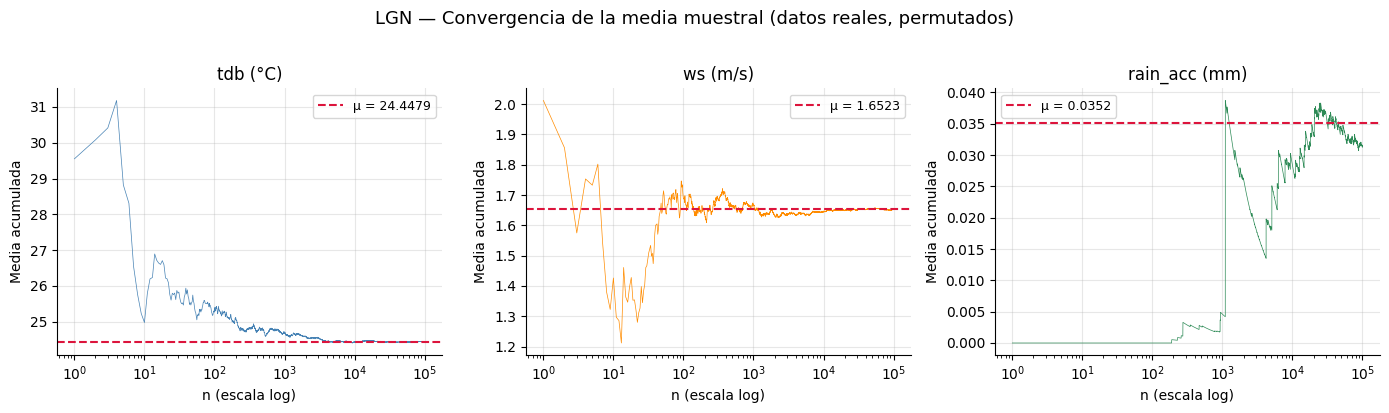

In [7]:
_max_n = min(100_000, len(tdb))

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
_ns = np.arange(1, _max_n + 1)

_configs_lgn = [
    (tdb, mu_tdb, "tdb (°C)", "steelblue"),
    (ws, mu_ws, "ws (m/s)", "darkorange"),
    (rain, mu_rain, "rain_acc (mm)", "seagreen"),
]

for ax, (datos, mu, nombre, color) in zip(axes2, _configs_lgn):
    # Permutar para romper la correlación temporal
    _shuffled = rng.permutation(datos)[:_max_n]
    _media_acum = np.cumsum(_shuffled) / _ns
    ax.plot(_ns, _media_acum, color=color, lw=0.5)
    ax.axhline(mu, color="crimson", ls="--", lw=1.5,
                label=f"μ = {mu:.4f}")
    ax.set_xscale("log")
    ax.set_xlabel("n (escala log)")
    ax.set_ylabel("Media acumulada")
    ax.set_title(nombre)
    ax.legend(fontsize=9)

plt.suptitle(
    "LGN — Convergencia de la media muestral (datos reales, permutados)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

> **Observaciones:**
> - Las tres variables convergen a $\mu$, a pesar de tener distribuciones
>   completamente distintas.
> - `rain_acc` converge más lento porque su varianza relativa es enorme
>   (casi todos los valores son 0, con picos ocasionales).
> - Permutamos los datos antes de acumular para simular un muestreo
>   aleatorio (los datos originales tienen autocorrelación temporal).


## 3. Teorema del Límite Central con datos reales

Para cada tamaño de muestra $n$, extraemos 1,000 muestras aleatorias,
calculamos la media de cada una, y graficamos la distribución resultante.

Según el TLC, esta distribución debe aproximarse a
$N(\mu,\;\sigma^2/n)$, sin importar la forma de la distribución
original.

### Elige la variable para explorar el TLC

In [8]:
var_dropdown = widgets.Dropdown(options=["tdb", "ws", "rain_acc"], value="tdb", description="Variable")

def _update(var_dropdown):
    _var = var_dropdown
    _info = poblacion_stats[_var]
    _datos = _info["datos"]
    _mu = _info["mu"]
    _sigma = _info["sigma"]

    _tamaños = [5, 30, 100, 500]
    _num_replicas = 1000

    fig3, axes3 = plt.subplots(2, 2, figsize=(11, 8))

    for ax, n_val in zip(axes3.flat, _tamaños):
        _medias = np.array(
            [rng.choice(_datos, size=n_val, replace=False).mean()
             for _ in range(_num_replicas)]
        )

        ax.hist(_medias, bins=40, density=True, color="steelblue",
                alpha=0.7, edgecolor="white", label="Empírica")

        # Curva normal teórica
        _de = _sigma / np.sqrt(n_val)
        _x = np.linspace(_medias.min(), _medias.max(), 200)
        _pdf = (
            1
            / (_de * np.sqrt(2 * np.pi))
            * np.exp(-0.5 * ((_x - _mu) / _de) ** 2)
        )
        ax.plot(_x, _pdf, "crimson", lw=2, label="$N(\\mu, \\sigma^2/n)$")
        ax.set_title(f"n = {n_val}")
        ax.set_xlabel("$\\bar{x}$")
        ax.set_ylabel("Densidad")
        ax.legend(fontsize=8)

    plt.suptitle(
        f"TLC — Variable: {_var}  (μ = {_mu:.3f},  σ = {_sigma:.3f})",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(_update, {'var_dropdown': var_dropdown})
display(widgets.VBox([var_dropdown, out]))

> **Prueba con las tres variables.** Observa que:
> - `tdb` (bimodal) se normaliza rápido porque cada "modo" ya es
>   simétrico. Con $n = 30$ el ajuste es excelente.
> - `ws` (asimétrica) necesita un poco más de $n$ para que las
>   colas se simetrizen.
> - `rain_acc` (cero-inflada) es el caso más extremo: con $n = 5$
>   la distribución de medias sigue siendo asimétrica; con $n = 500$
>   finalmente se ajusta a la normal.


## 4. Verificación numérica

Comparamos los valores teóricos ($\mu$ y $\sigma/\sqrt{n}$) con los
valores empíricos obtenidos de las 1,000 muestras.

In [ ]:
_tamaños = [5, 30, 100, 500]
_num_replicas = 1000
_rows = ""

for var_name, info in poblacion_stats.items():
    datos = info["datos"]
    mu = info["mu"]
    sigma = info["sigma"]

    for n_val in _tamaños:
        medias = np.array(
            [rng.choice(datos, size=n_val, replace=False).mean()
             for _ in range(_num_replicas)]
        )
        de_teorica = sigma / np.sqrt(n_val)
        de_empirica = medias.std()
        media_emp = medias.mean()

        _rows += (
            f"| `{var_name}` | {n_val} | {mu:.4f} | {media_emp:.4f} "
            f"| {de_teorica:.4f} | {de_empirica:.4f} |\n"
        )
display(Markdown(f"""
| Variable | n | μ (población) | $\\bar{{x}}$ medio (empírico) | DE teórica ($\\sigma/\\sqrt{{n}}$) | DE empírica |
|:---|---:|---:|---:|---:|---:|
{_rows}

> Los valores empíricos coinciden con los teóricos, confirmando
> que el TLC funciona incluso para distribuciones muy alejadas
> de la normal.
"""))


## 5. Nota sobre la autocorrelación temporal

En los ejercicios anteriores **permutamos** los datos para simular
muestreo aleatorio.  Pero los datos meteorológicos no son
independientes: la temperatura de un minuto está correlacionada con
la del minuto anterior.

¿Qué pasa si tomamos medias de bloques *consecutivos* en vez de
muestras aleatorias?

In [ ]:
_n = 30
_num_replicas = 1000

# Muestreo aleatorio (i.i.d.)
_medias_iid = np.array(
    [rng.choice(tdb, size=_n, replace=False).mean()
     for _ in range(_num_replicas)]
)

# Bloques consecutivos
_max_start = len(tdb) - _n
_starts = rng.integers(0, _max_start, _num_replicas)
_medias_bloque = np.array(
    [tdb[s : s + _n].mean() for s in _starts]
)

_de_teorica = sigma_tdb / np.sqrt(_n)

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax5a.hist(_medias_iid, bins=40, density=True, color="steelblue",
          alpha=0.7, edgecolor="white")
ax5a.set_title(f"Muestreo aleatorio  (DE = {_medias_iid.std():.3f})")
ax5a.set_xlabel("$\\bar{x}$")
ax5a.set_ylabel("Densidad")

ax5b.hist(_medias_bloque, bins=40, density=True, color="darkorange",
          alpha=0.7, edgecolor="white")
ax5b.set_title(f"Bloques consecutivos  (DE = {_medias_bloque.std():.3f})")
ax5b.set_xlabel("$\\bar{x}$")

# Normal teórica (solo aplica al i.i.d.)
_x = np.linspace(
    min(_medias_iid.min(), _medias_bloque.min()),
    max(_medias_iid.max(), _medias_bloque.max()),
    200,
)
_pdf = (
    1
    / (_de_teorica * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((_x - mu_tdb) / _de_teorica) ** 2)
)
ax5a.plot(_x, _pdf, "crimson", lw=2, label=f"$N(\\mu, \\sigma^2/n)$")
ax5b.plot(_x, _pdf, "crimson", lw=2, ls="--", alpha=0.5,
          label="Normal teórica (i.i.d.)")

ax5a.legend(fontsize=9)
ax5b.legend(fontsize=9)

plt.suptitle(
    f"Efecto de la autocorrelación en la distribución de $\\bar{{x}}$  "
    f"(n = {_n}, tdb)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

> **Conclusión importante:**
> - Con **muestreo aleatorio**, la dispersión de $\bar{x}$ coincide
>   con $\sigma/\sqrt{n}$ — el TLC funciona.
> - Con **bloques consecutivos** de 30 minutos, la dispersión es
>   **mucho mayor** que $\sigma/\sqrt{n}$, porque las observaciones
>   dentro de cada bloque son muy parecidas entre sí (autocorrelación).
>   30 minutos consecutivos no equivalen a 30 observaciones independientes.
>
> Este es un adelanto de por qué necesitaremos herramientas de
> **series temporales** (bloque 3) para analizar correctamente
> datos con dependencia temporal.


## Resumen de la sesión

| Verificación | Resultado con ClimaLab |
|:---|:---|
| **LGN** | Las tres variables (`tdb`, `ws`, `rain_acc`) convergen a $\mu$ — `rain_acc` más lento por su alta varianza relativa |
| **TLC** | La distribución de $\bar{x}$ se ajusta a $N(\mu, \sigma^2/n)$ incluso para `rain_acc` (cero-inflada), siempre que $n$ sea suficientemente grande |
| **Autocorrelación** | Bloques consecutivos violan la independencia → la dispersión real de $\bar{x}$ es mayor que la teórica. El TLC requiere muestras independientes |

**Próxima semana (5):** Usar estos resultados para construir
**intervalos de confianza** y medir la incertidumbre de nuestras
estimaciones.